# VisualAstro Color Guide

Visualastro offers many new colorsets and colormaps to choose from as well as color manipulation tools!

In [1]:
import matplotlib.pyplot as plt
import visualastro as va

plt.style.use('computer-modern-serif')
va.config.figsize = (5,5)

### Getting Colors in VisualAstro
visualastro recognizes many colors, from matplotlib's `named colors` to custom defined colorsets! To access any one of these colors use `get_colors`. This function is aware of many different named colors, color formats (hex, rgb, rgba), and custom colorsets. We can view our colors at any time using `va.plot_colorset` or `va.help.color`.

In [2]:
# get the turbo6 colorset
turbo6 = va.get_colors('turbo6')
print('turbo6 colorset: ', turbo6)

turbo6 colorset:  ['#35359a', '#4f65ff', '#5bffd9', '#c4ff05', '#ff7d3c', '#ab0449']


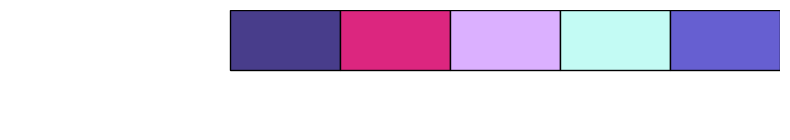

In [3]:
# named colors:
# any matplotlib named color, visualastro named color, xkcd color with or without 'xkcd:' !!!
va.help.color(va.get_colors(['darkslateblue', 'ibmpnk', 'unicorn', 'duck egg blue', 'xkcd:dark periwinkle']))

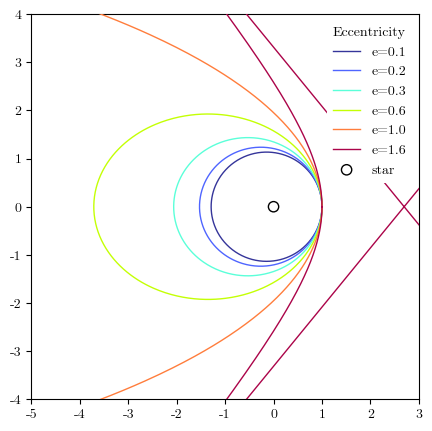

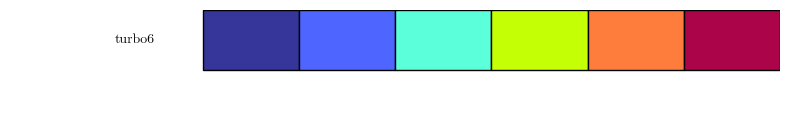

In [4]:
va.plot_colorset('turbo6')

va.help.color('turbo6', show_color_name=True)

### Changing How a Colorset Looks Like

We can change a colorset easily in visualastro using the `transform` keyword argument. The options are `'saturate'`, `'desaturate'`, and `'lighten'`, with the intensity of each effect controlled by `factor`.

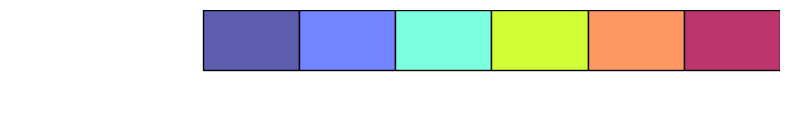

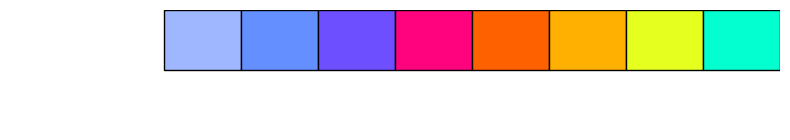

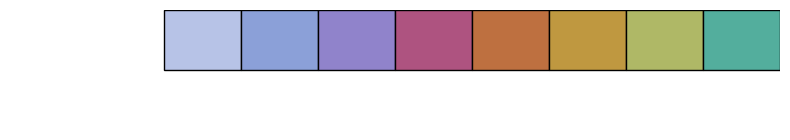

In [5]:
va.help.color(
    va.get_colors(
        ['#35359a', '#4f65ff', '#5bffd9', '#c4ff05', '#ff7d3c', '#ab0449'], 
        transform='lighten', 
        factor=0.2
    )
)
va.help.color(va.get_colors('astro_seq', transform='saturate', factor=1))
va.help.color(va.get_colors('astro_seq', transform='desaturate', factor=0.5))

Only one transform can be applied at the same time. To stack transforms, call the transformation functions directly on the returned colorset. All functions are available under the `get_complimentary_colors` api, or the individual functions `saturate_colors`, `desaturate_colors`, and `lighten_colors`.

### Sampling Colors From a Colormap

You can also pass an integer to `get_colors` to sample `N` colors from a colormap `cmap`. Set the range of the colormap with `cmap_range`, which by default is `(0,1)` (meaning use the entire range of the colormap). This can be done directly with the `sample_cmap` function.

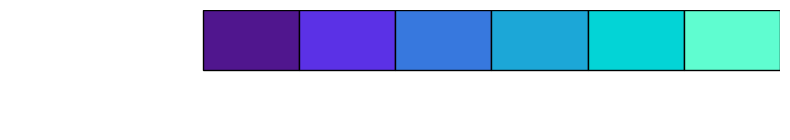

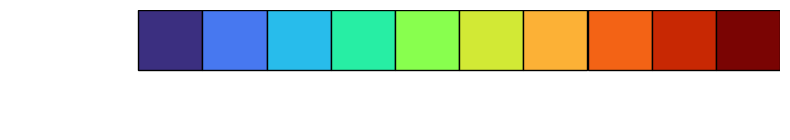

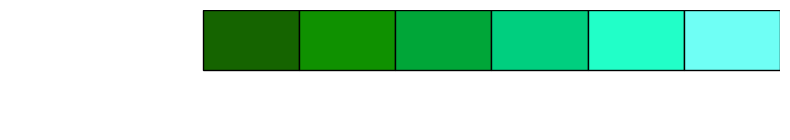

In [6]:
va.help.color(va.get_colors(6, cmap='cosmic', cmap_range=[0.3,1]))
va.help.color(va.get_colors(10, cmap='turbo', cmap_range=[0.04,1]))
va.help.color(va.get_colors(6, cmap='emerald', cmap_range=[0.3,1], transform='saturate', factor=1))

### CVD Simulations

We can also view how our colorset looks like under different colorblind spaces such as `'deuteranomaly'`, `'protanomaly'`, `'tritanomaly'`.
Pass any one of these to the `cvd_type` argument and `get_colors` returns what the colorset would look like in a colorblind colorspace. You can also pass in `'d'`, `'p'`, or `'t'` as a shorthand.

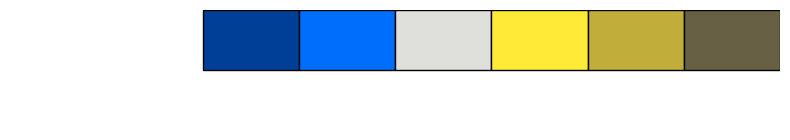

In [7]:
va.help.color(va.get_colors('turbo6', cvd_type='deuteranomaly', severity=100))

You can also simulate the cvd space directly with `help.color`. We can pass in `'all'` to `cvd_type` to show all 3 types! As you can see, `'turbo6'` is colorblind safe!

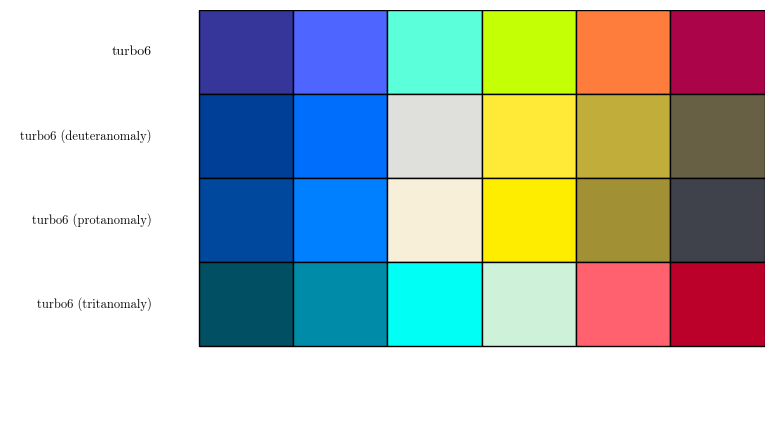

In [8]:
va.help.color('turbo6', cvd_type='all', show_color_name=True)

### Advanced CVD Analysis

We can also plot the $\Delta E*$ of a colorset, which computes the pairwise color difference matrix of a colorset in `CIELab` space using the `colorspacious` package. Given a sequence of colors, this tells you how different each pair of colors is. The placement of each color in the matrix is indicated by the color of the tick mark. The diagonal is white because this represents the color difference between a color with itself (which is zero or nan). Ideally, you want each color pair to have a high $\Delta E*$, to ensure they are above the just-noticeable-difference (JND) threshold.

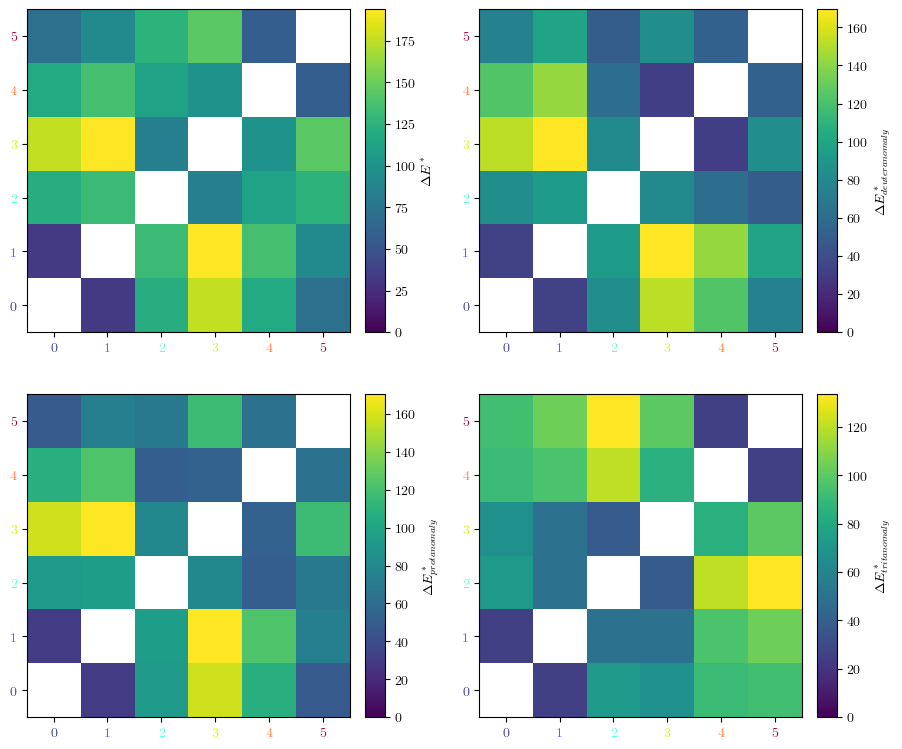

In [9]:
_ = va.plot_color_deltaE('turbo6')

We can also plot the normalized $\Delta E*$ plots where we divide each cvd simulation $\Delta E*$ matrix by the non cvd space matrix. While the above plot tells you how far two colors are in CIELab space, the normalized plot tells you how consistent a colorset is under colorblindness. A $\Delta E*$ of 1 means the pair's perceptual distance under CVD equals the distance under normal vision (no distinguishability loss). As we can see below, the visualastro `turbo6` colorset is colorblind safe!

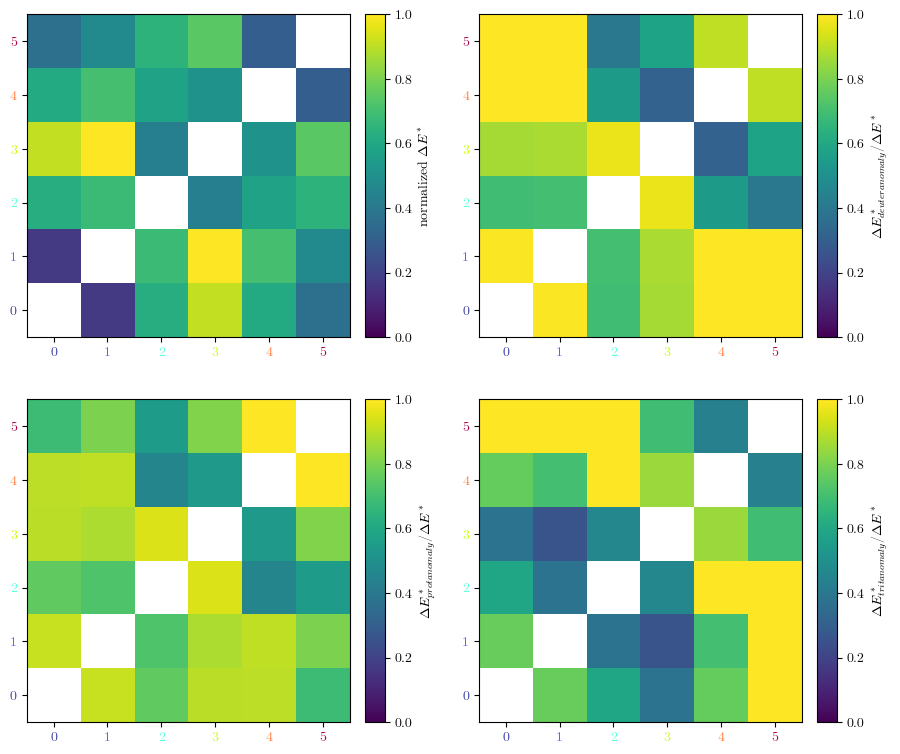

In [10]:
_ = va.plot_color_deltaE('turbo6', normalize=True)

If we look at rgb, however, we can see that red and green suffer in both `'deuteranomaly'` and `'protanomaly'` colorspaces.

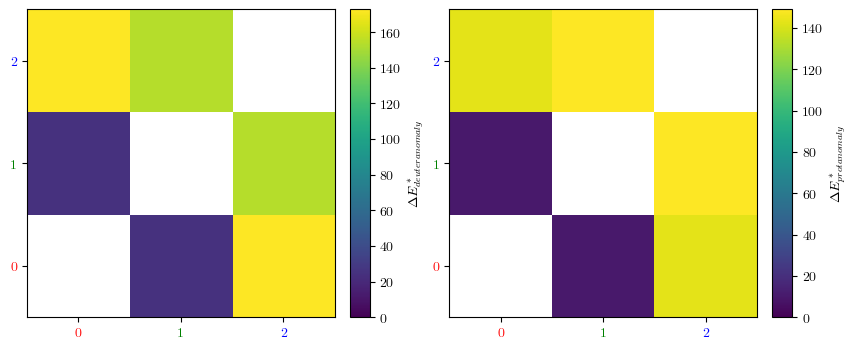

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))
_ = va.plot_color_deltaE(['r', 'g', 'b'], cvd_type='deuteranomaly', ax=ax[0])
_ = va.plot_color_deltaE(['r', 'g', 'b'], cvd_type='protanomaly', ax=ax[1])

### Setting the Format
We can also specify the format of the output colors with `fmt`. 

In [12]:
va.get_colors('ibm', fmt='rgb')

[(0.39215686274509803, 0.5607843137254902, 1.0),
 (0.47058823529411764, 0.3686274509803922, 0.9411764705882353),
 (0.8627450980392157, 0.14901960784313725, 0.4980392156862745),
 (0.996078431372549, 0.3803921568627451, 0.0),
 (1.0, 0.6901960784313725, 0.0)]

In [13]:
va.get_colors('ibm', fmt='rgba')

[(0.39215686274509803, 0.5607843137254902, 1.0, 1.0),
 (0.47058823529411764, 0.3686274509803922, 0.9411764705882353, 1.0),
 (0.8627450980392157, 0.14901960784313725, 0.4980392156862745, 1.0),
 (0.996078431372549, 0.3803921568627451, 0.0, 1.0),
 (1.0, 0.6901960784313725, 0.0, 1.0)]

In [14]:
va.get_colors('ibm', fmt='hex')

['#648fff', '#785ef0', '#dc267f', '#fe6100', '#ffb000']

### See All Colorsets

You can also do `va.help.color(cvd_type='all')` to see the each colorset in cvd space.

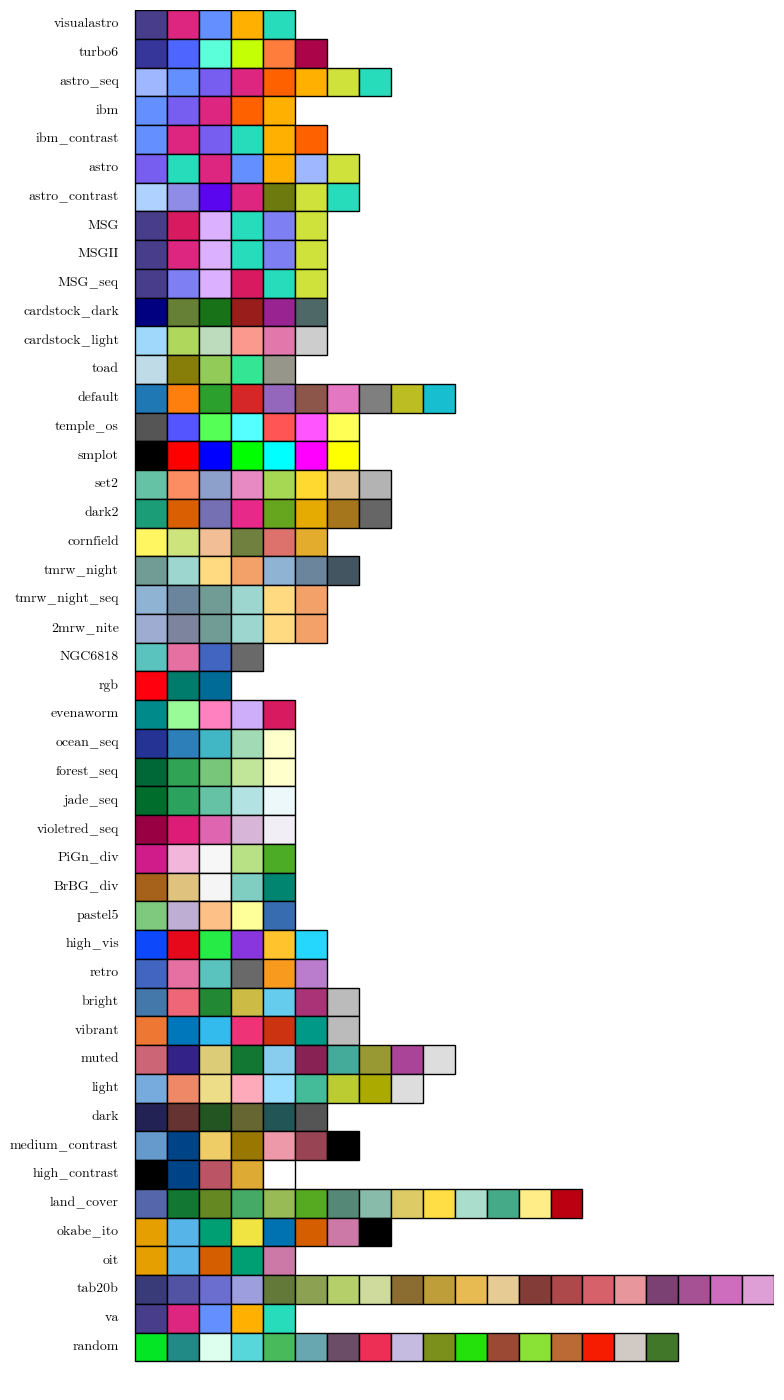

In [38]:
va.help.color()

### Cool Other Stuff

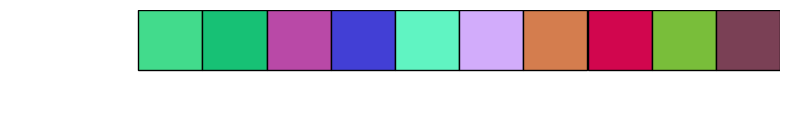

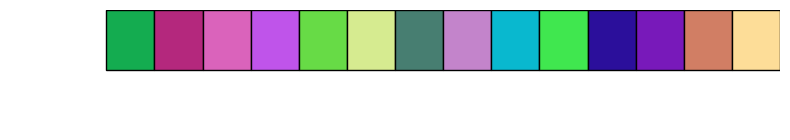

In [62]:
# get random colors! This will return N random colors each time you run the function!
va.help.color(va.random_colors(10))

# or use `get_colors`! The number of colors here is set by `va.config.random_colors_max_N`
va.help.color(va.get_colors('random'))